---
title: "Interpreting Results with TabPFN"
description: "Learn how to use the standard interpretability toolkit with TabPFN for explainable results"
cookbookTags:
  - interpretability
authors:
  - name: Prior Labs
    linkedin: https://www.linkedin.com/company/prior-labs
    twitter: https://twitter.com/prior_labs
---

*With SHAP values and partial dependence plots.*

A strong classifier is only useful in practice if you can explain what it is doing. TabPFN works with the standard interpretability toolkit, so the same SHAP and partial-dependence techniques you would use on any model apply directly. Working with a coronary-disease dataset, this notebook covers global feature importance, how predictions respond to each feature, and how to explain individual patient predictions.

## Setup

*Installing TabPFN, its interpretability extensions, and SHAP.*

`tabpfn_extensions` provides the interpretability helpers used here; `shap` provides the explainer and plots.

In [ ]:
!pip install tabpfn tabpfn_extensions scikit-learn shap

In [ ]:
import os

from google.colab import userdata

import warnings
from pathlib import Path

import matplotlib

import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn_extensions import TabPFNClassifier
from tabpfn_extensions.interpretability import pdp as tabpfn_pdp

warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.
/opt/homebrew/Caskroom/miniconda/base/envs/cookbook/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
os.environ["TABPFN_TOKEN"] = userdata.get('TABPFN_TOKEN')

## Loading the Data

*A coronary-disease dataset, relabelled for readable explanations.*

We use the heart-statlog dataset. Interpretability is only as clear as the feature names, so we rename the columns to plain language and keep a decoding map for categorical values. This makes every plot below far easier to read.

### Readable names and categories

*Mapping column names and codes to human-readable labels.*

In [5]:
# @title
RENAME = {
    "age": "Age",
    "sex": "Sex",
    "chest": "Chest pain type",
    "resting_blood_pressure": "Resting BP",
    "serum_cholestoral": "Cholesterol",
    "fasting_blood_sugar": "High fasting sugar",
    "resting_electrocardiographic_results": "Resting ECG",
    "maximum_heart_rate_achieved": "Max heart rate",
    "exercise_induced_angina": "Exercise angina",
    "oldpeak": "ST depression",
    "slope": "ST slope",
    "number_of_major_vessels": "Blocked vessels",
    "thal": "Thallium scan",
}
DECODE = {
    "Sex": {0: "female", 1: "male"},
    "Chest pain type": {1: "typical angina", 2: "atypical angina", 3: "non-anginal", 4: "asymptomatic"},
    "High fasting sugar": {0: "no", 1: "yes"},
    "Resting ECG": {0: "normal", 1: "ST-T abnormality", 2: "LV hypertrophy"},
    "Exercise angina": {0: "no", 1: "yes"},
    "ST slope": {1: "upsloping", 2: "flat", 3: "downsloping"},
    "Thallium scan": {3: "normal", 6: "fixed defect", 7: "reversible defect"},
}
CATEGORICAL = ["Sex", "Chest pain type", "High fasting sugar", "Resting ECG",
               "Exercise angina", "ST slope", "Thallium scan"]
CONTINUOUS = ["Age", "Resting BP", "Cholesterol", "Max heart rate", "ST depression", "Blocked vessels"]

In [7]:
raw = fetch_openml("heart-statlog", version=1, as_frame=True)
X = raw.data.astype(float).rename(columns=RENAME)
y = (raw.target == "present").astype(int)
feature_names = list(X.columns)
cat_idx = [feature_names.index(c) for c in CATEGORICAL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=200, test_size=70, random_state=42, stratify=y
)

## Fit and Predict

*Training the classifier we are going to explain.*

We fit `TabPFNClassifier`, passing the categorical feature indices so the model treats them correctly, and keep the predicted probabilities for the test set.

In [8]:
clf = TabPFNClassifier(fit_mode="fit_with_cache", categorical_features_indices=cat_idx)
clf.fit(X_train.values, y_train.values)
proba_test = clf.predict_proba(X_test.values)[:, 1]

## Global Feature Importance

*SHAP values across the whole test set.*

A permutation SHAP explainer attributes each prediction to its features. The beeswarm plot summarises every patient at once: horizontal position shows whether a feature pushed risk up or down, colour shows whether the feature value was high or low.

PermutationExplainer explainer: 71it [01:23,  1.34s/it]                        


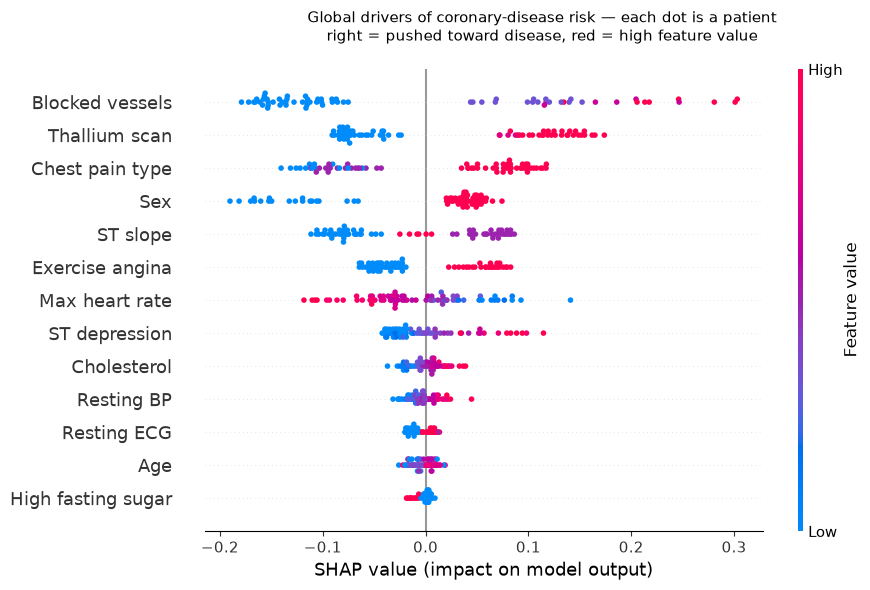

In [30]:
predict = lambda A: clf.predict_proba(np.asarray(A))[:, 1]
background = shap.sample(X_train, 50, random_state=42)
explainer = shap.PermutationExplainer(predict, background)

sv = explainer(X_test, max_evals=2 * len(feature_names) + 1)
sv.display_data = X_test.values
shap.plots.beeswarm(sv, max_display=len(feature_names), show=False)

fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle(
    "Global drivers of coronary-disease risk — each dot is a patient\n"
    "right = pushed toward disease, red = high feature value",
    fontsize=11,
)

plt.show()

## Partial Dependence

*How average predicted risk moves with each measurement.*

Where SHAP shows attribution, partial dependence shows shape. For the top continuous features we trace how the average predicted probability changes as we sweep each one across its range.

Partial dependence for: ['Blocked vessels', 'Max heart rate', 'ST depression', 'Cholesterol']


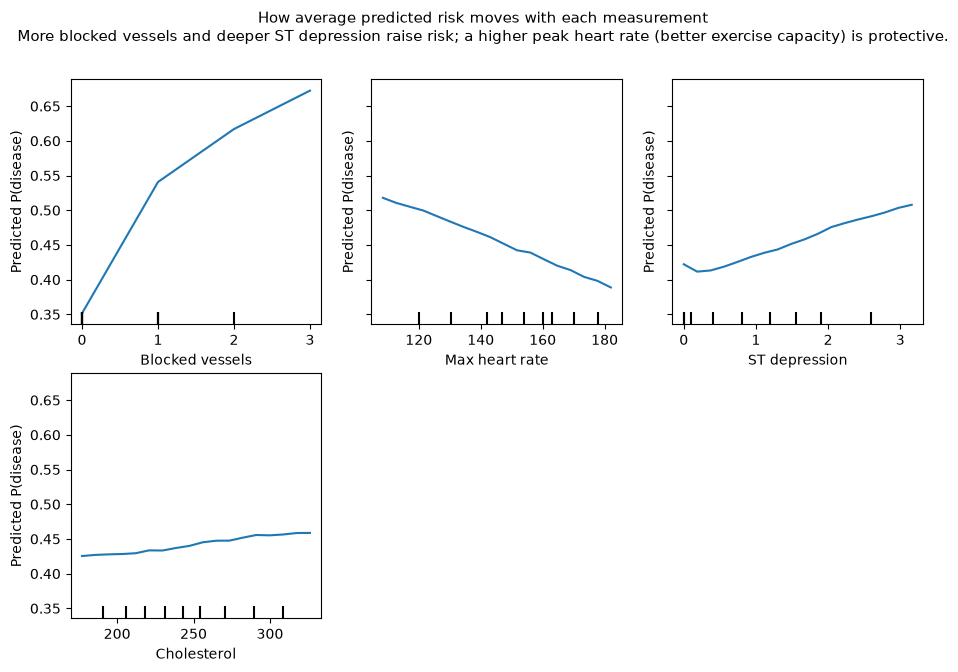

In [31]:
mean_abs = np.abs(sv.values).mean(0)
ranking = np.argsort(-mean_abs)

cont_ranked = [i for i in ranking if feature_names[i] in CONTINUOUS][:4]
print(f"Partial dependence for: {[feature_names[i] for i in cont_ranked]}")
disp = tabpfn_pdp.partial_dependence_plots(
    clf, X_train.values, features=list(cont_ranked),
    grid_resolution=18, kind="average", target_class=1,
)
fig = disp.figure_
fig.set_size_inches(11, 7)
for ax, fi in zip(np.ravel(disp.axes_), cont_ranked):
    ax.set_xlabel(feature_names[fi])
    ax.set_ylabel("Predicted P(disease)")
fig.suptitle(
    "How average predicted risk moves with each measurement\n"
    "More blocked vessels and deeper ST depression raise risk; a higher peak heart "
    "rate (better exercise capacity) is protective.",
    fontsize=11,
)
plt.show()

## Explaining Individual Predictions

*Waterfall explanations for specific patients.*

Global views aside, clinicians reason about individuals. Starting from the population base rate, a waterfall plot shows exactly which features moved a single patient's predicted risk up or down. We look at the highest-risk, lowest-risk, and a borderline patient.

In [26]:
# @title
p = sv.values.sum(1) + sv.base_values
idx_high = int(np.argmax(p)) # Highest risk patient
idx_low = int(np.argmin(p)) # Lowest risk patient
idx_borderline = int(np.argmin(np.abs(p - 0.5)))
base_rate = float(sv.base_values[0])

print(f"Every explanation starts from the population base rate of {base_rate:.0%}.\n")


def show_value(name, v):
    if name in DECODE:
        return DECODE[name].get(int(v), str(v))
    return f"{v:g}"


def describe(idx, label):
    row = sv[idx]
    vals = X_test.iloc[idx]
    row.display_data = np.array(
        [show_value(feature_names[j], vals.iloc[j]) for j in range(len(feature_names))],
        dtype=object,
    )
    print(f"[{label}] predicted risk = {p[idx]:.0%}  (base rate {base_rate:.0%})")
    for j in np.argsort(-np.abs(row.values))[:5]:
        name = feature_names[j]
        arrow = "raises" if row.values[j] > 0 else "lowers"
        print(
            f"    {name:<18} = {show_value(name, vals.iloc[j]):<18} {arrow} risk by "
            f"{abs(row.values[j]) * 100:4.1f} points"
        )
    print()
    shap.plots.waterfall(row, show=False)
    fig = plt.gcf()
    fig.set_size_inches(9, 5)
    fig.suptitle(f"{label}: predicted coronary-disease risk {p[idx]:.0%}", fontsize=11)
    return fig

Every explanation starts from the population base rate of 53%.



[Highest-risk patient] predicted risk = 100%  (base rate 53%)
    Blocked vessels    = 3                  raises risk by 16.1 points
    Chest pain type    = asymptomatic       raises risk by  8.1 points
    ST slope           = flat               raises risk by  6.2 points
    Thallium scan      = reversible defect  raises risk by  6.1 points
    Exercise angina    = yes                raises risk by  4.7 points



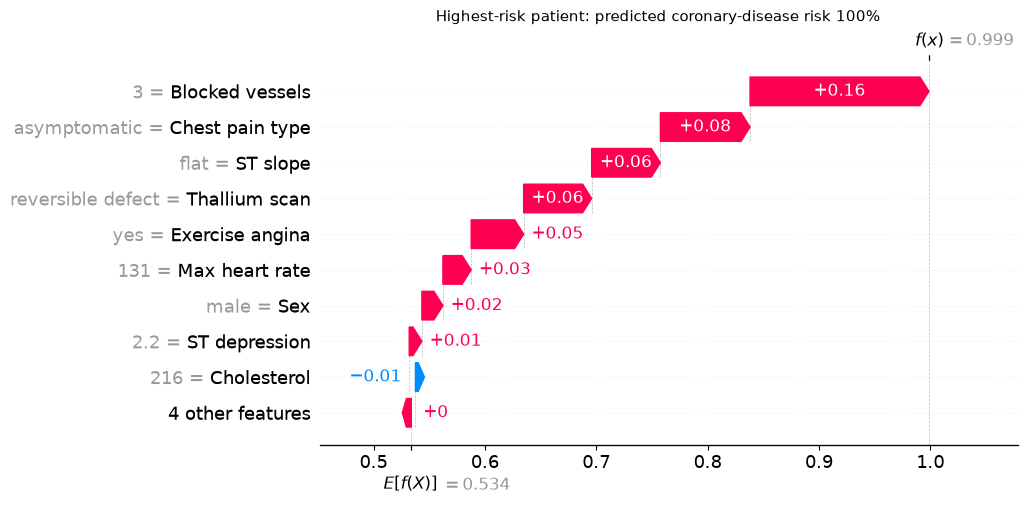

In [27]:
fig = describe(idx_high, "Highest-risk patient")
plt.show()

[Lowest-risk patient] predicted risk = 1%  (base rate 53%)
    Blocked vessels    = 0                  lowers risk by  9.8 points
    Chest pain type    = non-anginal        lowers risk by  8.9 points
    ST slope           = upsloping          lowers risk by  7.8 points
    Sex                = female             lowers risk by  7.7 points
    Exercise angina    = no                 lowers risk by  4.3 points



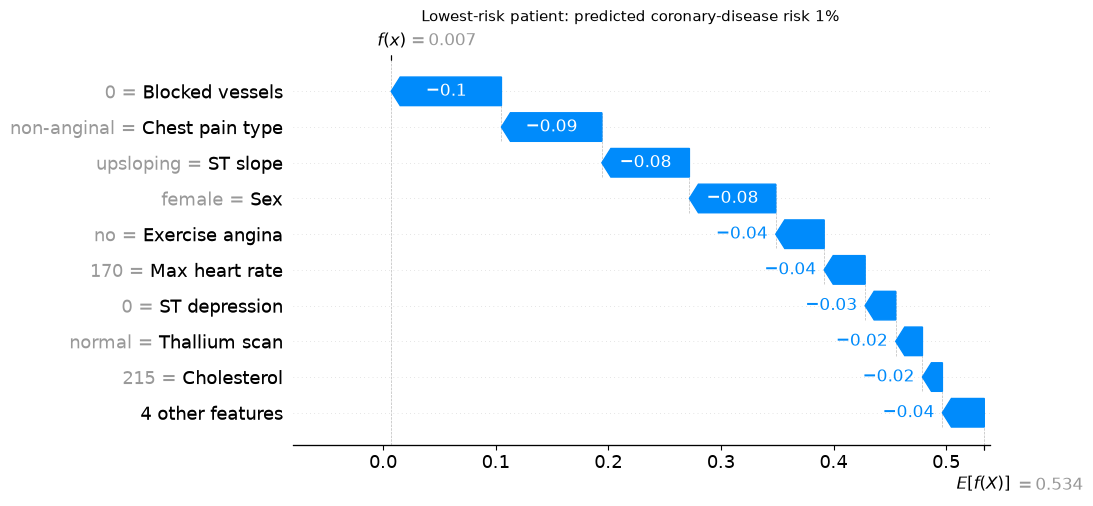

In [28]:
fig = describe(idx_low, "Lowest-risk patient")
plt.show()

[Borderline patient] predicted risk = 47%  (base rate 53%)
    Blocked vessels    = 0                  lowers risk by 15.3 points
    Thallium scan      = reversible defect  raises risk by 14.9 points
    Chest pain type    = typical angina     lowers risk by 13.2 points
    ST slope           = flat               raises risk by  7.2 points
    Sex                = male               raises risk by  5.5 points



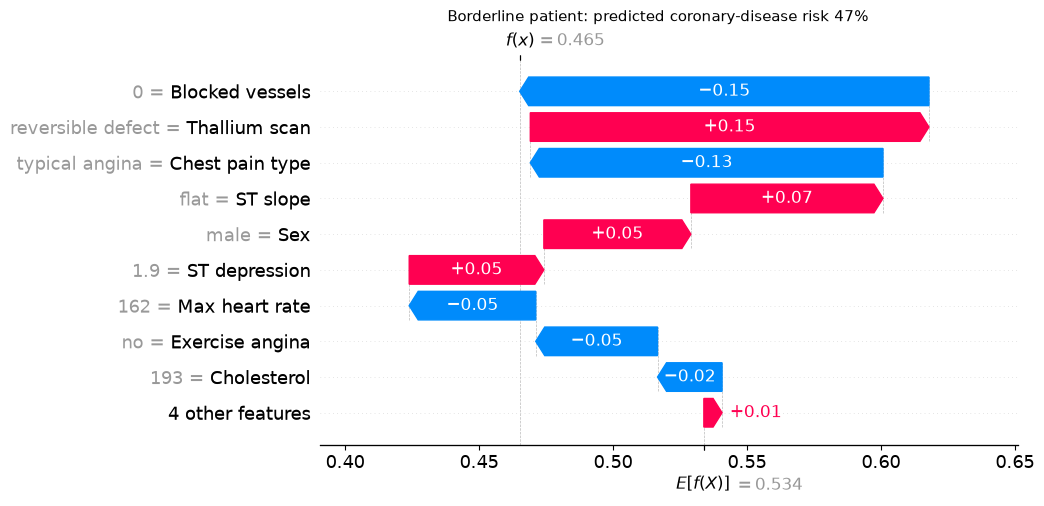

In [29]:
fig = describe(idx_borderline, "Borderline patient")
plt.show()